# 문과생을 위한 주성분분석(PCA) — iris 실습 노트북

붓꽃(iris) 자료로 PCA의 일곱 단계를 처음부터 끝까지 직접 실행한다. 손계산은 하지 않고,
`scikit-learn`의 고수준 도구만으로 검증한다. 표는 `polars`로 보여 준다.

> 행렬·전치·대칭·직교가 헷갈리면 책의 **0부**를, 각 단계의 뜻은 **3부**를 함께 본다.

## 0. 한글 그림 글꼴 준비

그래프에 한글이 깨지지 않도록 글꼴을 등록한다. (환경에 따라 자동으로 건너뛴다.)

In [1]:
import matplotlib, matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_cands = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
_name = None
for _f in _cands:
    try:
        fm.fontManager.addfont(_f)
        _name = fm.FontProperties(fname=_f).get_name()
        break
    except Exception:
        pass
if _name:
    plt.rcParams["font.family"] = _name
plt.rcParams["axes.unicode_minus"] = False
print("한글 글꼴:", _name or "기본값 사용")

한글 글꼴: Noto Sans CJK JP


## 1. 자료 가져오기 — iris (150송이 × 4변수)

`load_iris` 한 줄로 자료를 불러온다. 가로줄 하나가 꽃 한 송이, 세로줄 하나가 한 변수다.
표는 `polars` 데이터프레임으로 살펴본다.

In [2]:
import polars as pl
from sklearn.datasets import load_iris

iris = load_iris()
cols = ["꽃받침길이", "꽃받침너비", "꽃잎길이", "꽃잎너비"]
df = pl.DataFrame(iris.data, schema=cols)
df = df.with_columns(pl.Series("품종", [iris.target_names[i] for i in iris.target]))
print("자료 크기:", df.shape)   # (150, 5)
df.head()

자료 크기: (150, 5)


꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종
f64,f64,f64,f64,str
5.1,3.5,1.4,0.2,"""setosa"""
4.9,3.0,1.4,0.2,"""setosa"""
4.7,3.2,1.3,0.2,"""setosa"""
4.6,3.1,1.5,0.2,"""setosa"""
5.0,3.6,1.4,0.2,"""setosa"""


변수별 요약 통계도 `polars`로 한눈에 본다. 네 변수의 평균과 퍼짐(표준편차)이
제각각임을 확인한다 — 그래서 다음 단계의 **표준화**가 필요하다.

In [3]:
df.select(cols).describe()

statistic,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비
str,f64,f64,f64,f64
"""count""",150.0,150.0,150.0,150.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",5.843333,3.057333,3.758,1.199333
"""std""",0.828066,0.435866,1.765298,0.762238
"""min""",4.3,2.0,1.0,0.1
"""25%""",5.1,2.8,1.6,0.3
"""50%""",5.8,3.0,4.4,1.3
"""75%""",6.4,3.3,5.1,1.8
"""max""",7.9,4.4,6.9,2.5


## 2. 1·2단계 — 센터링과 표준화

평균을 빼고(센터링) 표준편차로 나눈다(표준화). 표준화를 마치면 네 변수가 모두
평균 0, 표준편차 1이 되어 같은 척도가 된다. ‘사과와 코끼리를 같은 저울에 올리는’ 일이다.

In [4]:
from sklearn.preprocessing import StandardScaler

Z = StandardScaler().fit_transform(iris.data)
print("표준화 후 평균:", Z.mean(axis=0).round(2))   # [0 0 0 0]
print("표준화 후 표준편차:", Z.std(axis=0).round(2)) # [1 1 1 1]

표준화 후 평균: [-0. -0. -0. -0.]
표준화 후 표준편차: [1. 1. 1. 1.]


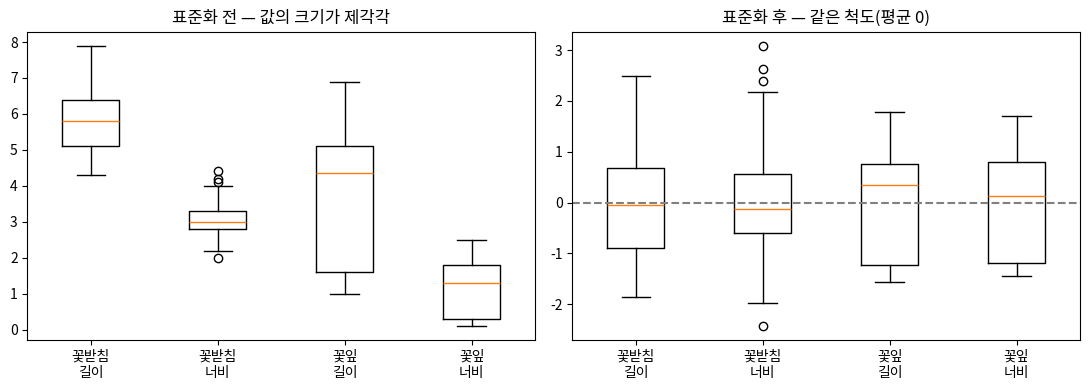

In [5]:
# 표준화 전과 후의 분포 비교
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
short = ["꽃받침\n길이", "꽃받침\n너비", "꽃잎\n길이", "꽃잎\n너비"]
ax[0].boxplot(iris.data, tick_labels=short); ax[0].set_title("표준화 전 — 값의 크기가 제각각")
ax[1].boxplot(Z, tick_labels=short); ax[1].axhline(0, color="gray", ls="--")
ax[1].set_title("표준화 후 — 같은 척도(평균 0)")
plt.tight_layout(); plt.show()

## 3. 3·4·5단계 — 방향 찾기 (`PCA().fit` 한 줄)

공분산행렬을 만들고(3단계), 자료가 가장 넓게 퍼지는 방향들을 찾고(4단계),
대칭의 마법으로 깔끔하게 쪼개는(5단계) 일이 모두 `PCA().fit` 한 줄 안에서 일어난다.

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA().fit(Z)
evr = pca.explained_variance_ratio_
print("각 PC가 설명하는 정보 비율:", evr.round(4))
print("누적 비율:", np.cumsum(evr).round(4))

각 PC가 설명하는 정보 비율: [0.7296 0.2285 0.0367 0.0052]
누적 비율: [0.7296 0.9581 0.9948 1.    ]


PC1이 약 73%, PC2가 약 23%를 설명한다. 두 방향을 더하면 **96%**다.
나머지 두 방향은 합쳐도 5%가 안 되므로, 자료는 사실상 두 방향으로 거의 다 설명된다.

## 4. 6단계 — PC 스코어 (각 꽃을 새 좌표로)

각 꽃을 새 좌표(PC1, PC2)의 값으로 옮겨 적는다. 네 숫자로 적던 꽃을 두 숫자로 다시 적는 셈이다.
결과를 `polars` 표로 본다.

In [7]:
scores = pca.transform(Z)
sc = pl.DataFrame(scores[:, :2], schema=["PC1", "PC2"])
sc = sc.with_columns(pl.Series("품종", [iris.target_names[i] for i in iris.target]))
sc.head()

PC1,PC2,품종
f64,f64,str
-2.264703,0.480027,"""setosa"""
-2.080961,-0.674134,"""setosa"""
-2.364229,-0.341908,"""setosa"""
-2.299384,-0.597395,"""setosa"""
-2.389842,0.646835,"""setosa"""


## 5. 7단계 — 차원 축소와 결과 그림

큰 방향 둘만 남긴다. 먼저 누적 정보를 막대·선으로 확인한다.

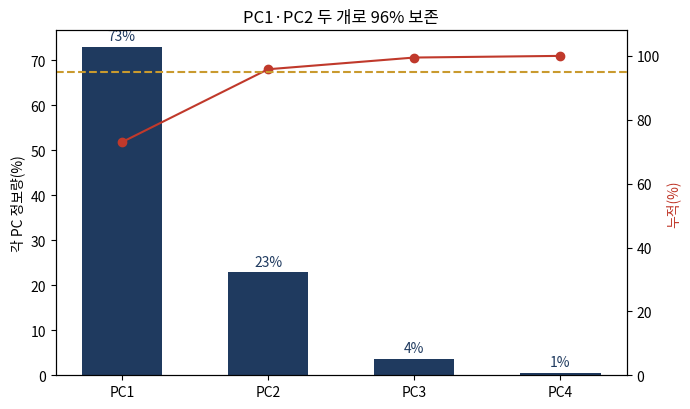

In [8]:
cum = np.cumsum(evr)
xs = np.arange(1, 5)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(xs, evr*100, color="#1F3A5F", width=0.55)
ax2 = ax.twinx()
ax2.plot(xs, cum*100, color="#C0392B", marker="o")
ax2.axhline(95, color="#C99A2E", ls="--"); ax2.set_ylim(0, 108)
for x, e in zip(xs, evr): ax.text(x, e*100+1.5, f"{e*100:.0f}%", ha="center", color="#1F3A5F")
ax.set_xticks(xs); ax.set_xticklabels([f"PC{i}" for i in xs])
ax.set_ylabel("각 PC 정보량(%)"); ax2.set_ylabel("누적(%)", color="#C0392B")
ax.set_title("PC1·PC2 두 개로 96% 보존"); plt.tight_layout(); plt.show()

PC1·PC2 두 축만으로 평면에 펼쳐 세 품종을 그린다.

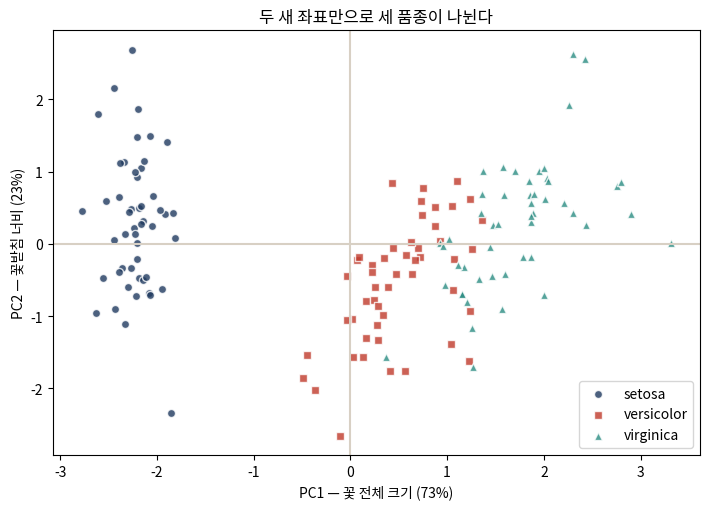

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
cmap = ["#1F3A5F", "#C0392B", "#2A8C82"]; marks = ["o", "s", "^"]
for k, name in enumerate(iris.target_names):
    m = iris.target == k
    ax.scatter(scores[m, 0], scores[m, 1], c=cmap[k], marker=marks[k],
               s=34, alpha=0.8, edgecolor="white", label=name)
ax.axhline(0, color="#D8D0C4"); ax.axvline(0, color="#D8D0C4")
ax.set_xlabel("PC1 — 꽃 전체 크기 (73%)"); ax.set_ylabel("PC2 — 꽃받침 너비 (23%)")
ax.set_title("두 새 좌표만으로 세 품종이 나뉜다"); ax.legend()
plt.tight_layout(); plt.show()

**setosa**(파란 동그라미)는 PC1 값이 모두 음수인 왼쪽에 뭉쳐, **PC1 한 축만으로** 완전히 분리된다.

## 6. 새 축의 정체 — PC1과 PC2는 무엇인가

각 변수가 새 축에 기여하는 정도를 보면 새 축의 뜻이 드러난다.

In [10]:
load = pl.DataFrame({
    "변수": cols,
    "PC1_기여": pca.components_[0].round(3),
    "PC2_기여": pca.components_[1].round(3),
})
load

변수,PC1_기여,PC2_기여
str,f64,f64
"""꽃받침길이""",0.521,0.377
"""꽃받침너비""",-0.269,0.923
"""꽃잎길이""",0.58,0.024
"""꽃잎너비""",0.565,0.067


- **PC1**: 꽃받침 길이·꽃잎 길이·꽃잎 너비가 함께 크게 기여 → **‘꽃 전체 크기’** 축
- **PC2**: 꽃받침 너비 하나가 0.92로 압도 → 사실상 **‘꽃받침 너비’** 축

붓꽃 한 송이는 ‘얼마나 큰가(PC1)’와 ‘꽃받침이 얼마나 넓은가(PC2)’ 두 가지로 거의 다 설명되며,
이 두 축만으로 세 품종이 갈린다. 네 변수를 뜻 있는 두 변수로 압축해 낸 것이 PCA가 한 일이다.